# 📊 Análise Exploratória de Leads - Corretora Internacional

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-muted')
sns.set_palette('muted')

# Caminho para o CSV processado
df_path = Path.cwd().parent / "Data" / "PROCESSED" / "leads_processados_para_pbi.csv"
df = pd.read_csv(df_path, parse_dates=["data_cadastro"])
df.head()


,lead_id,origem,data_cadastro,status_conversao,dias_ate_1o_trade,valor_deposito,perfil,pais,foi_convertido,ano_mes_cadastro
0,2001,Orgânico,2025-03-29,Não Convertido,NaN,0.00,NaN,Brasil,False,2025-03
1,2002,Instagram,2025-03-10,Não Convertido,NaN,0.00,NaN,Portugal,False,2025-03
2,2003,Orgânico,2025-02-20,Convertido,6.0,7985.78,Scalper,Espanha,True,2025-02
3,2004,Facebook,2025-03-13,Convertido,7.0,6026.72,Investidor,Brasil,True,2025-03
4,2005,Orgânico,2025-01-28,Convertido,6.0,4513.74,Investidor,Espanha,True,2025-01


## 📌 Informações Gerais

In [5]:
print("Total de linhas:", len(df))
print("Total de colunas:", len(df.columns))



Total de linhas: 300
Total de colunas: 10


In [7]:
display("Colunas disponíveis:", list(df.columns))
print("\nTipos de dados:")
print(df.dtypes)


'Colunas disponíveis:'

['lead_id',
 'origem',
 'data_cadastro',
 'status_conversao',
 'dias_ate_1o_trade',
 'valor_deposito',
 'perfil',
 'pais',
 'foi_convertido',
 'ano_mes_cadastro']


Tipos de dados:
lead_id                       int64
origem                       object
data_cadastro        datetime64[ns]
status_conversao             object
dias_ate_1o_trade           float64
valor_deposito              float64
perfil                       object
pais                         object
foi_convertido                 bool
ano_mes_cadastro             object
dtype: object


In [9]:
print("\nValores ausentes por coluna:")
display(df.isnull().sum())


Valores ausentes por coluna:


lead_id                0
origem                 0
data_cadastro          0
status_conversao       0
dias_ate_1o_trade    109
valor_deposito         0
perfil               109
pais                   0
foi_convertido         0
ano_mes_cadastro       0
dtype: int64

## 📈 Quantidade de Leads por Plataforma (Origem)

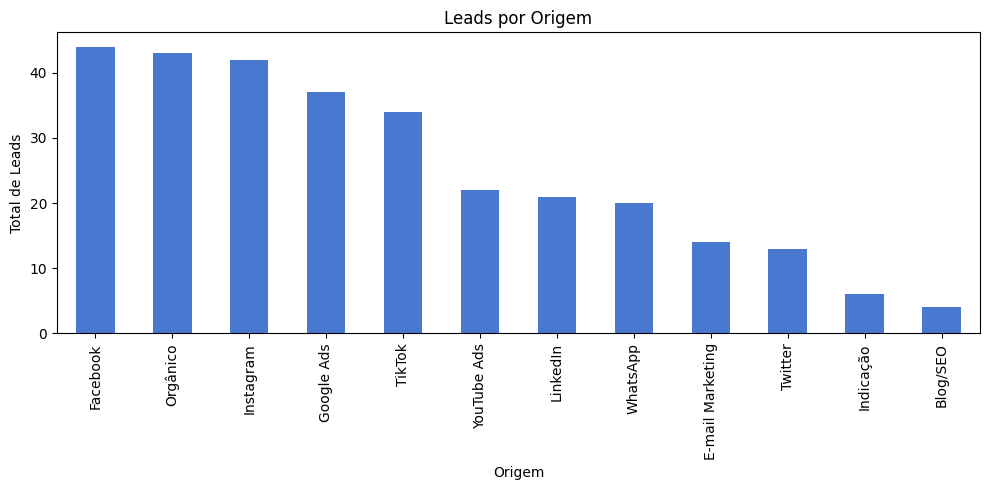

In [10]:
df['origem'].value_counts().plot(kind='bar', figsize=(10,5), title='Leads por Origem')
plt.xlabel("Origem"); plt.ylabel("Total de Leads")
plt.tight_layout()
plt.show()


## 🔄 Taxa de Conversão por Origem

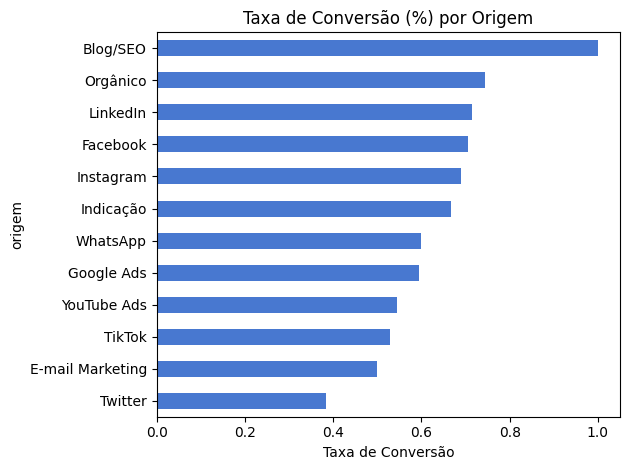

In [11]:
conv = df.groupby('origem')['status_conversao'].value_counts(normalize=True).unstack().fillna(0)
conv['Convertido'].sort_values().plot(kind='barh', title='Taxa de Conversão (%) por Origem')
plt.xlabel("Taxa de Conversão")
plt.tight_layout()
plt.show()


## ⏱️ Tempo Médio até o 1º Trade por Origem

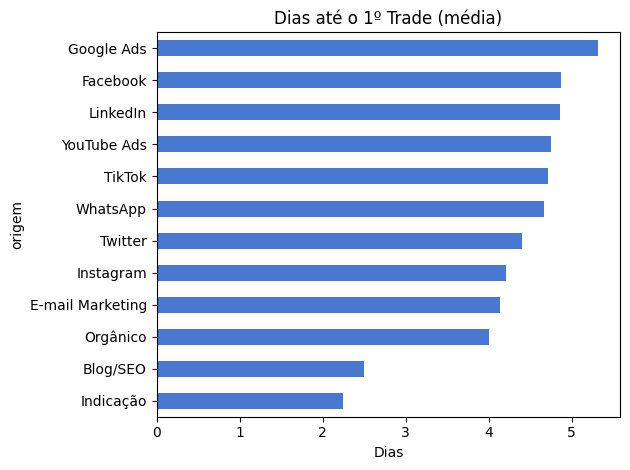

In [12]:
df[df['dias_ate_1o_trade'].notnull()].groupby('origem')['dias_ate_1o_trade'].mean().sort_values().plot(kind='barh', title='Dias até o 1º Trade (média)')
plt.xlabel("Dias"); plt.tight_layout(); plt.show()


## 💰 Valor Médio de Depósito por Plataforma

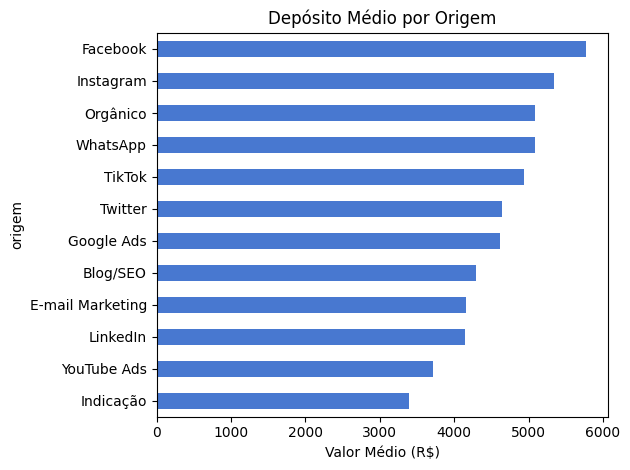

In [13]:
df[df['valor_deposito'] > 0].groupby('origem')['valor_deposito'].mean().sort_values().plot(kind='barh', title='Depósito Médio por Origem')
plt.xlabel("Valor Médio (R$)")
plt.tight_layout()
plt.show()


## 🌍 País com Maior Número de Leads Convertidos

pais
Argentina    43
Brasil       40
Portugal     39
Espanha      36
México       33
Name: count, dtype: int64


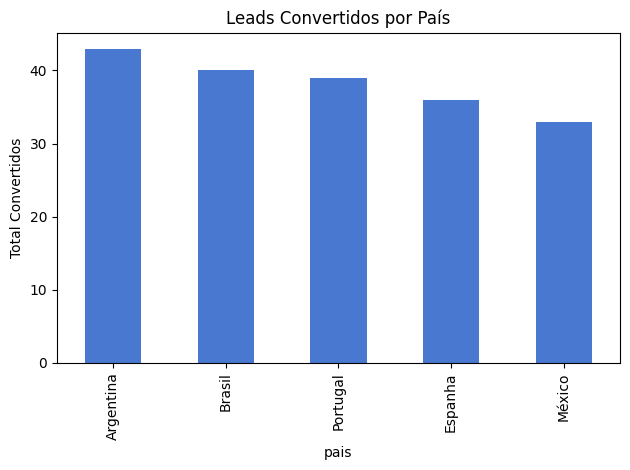

In [14]:
pais_convertidos = df[df['status_conversao'] == 'Convertido']['pais'].value_counts()
print(pais_convertidos.head(5))
pais_convertidos.plot(kind='bar', title='Leads Convertidos por País')
plt.ylabel("Total Convertidos")
plt.tight_layout()
plt.show()


## 💸 País com Maior Volume de Investimento

pais
Portugal     212268.87
Brasil       202536.59
Argentina    202463.72
Espanha      171889.00
México       149107.67
Name: valor_deposito, dtype: float64


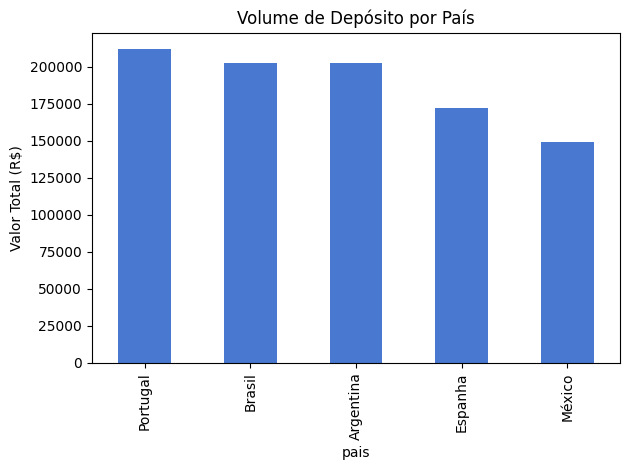

In [15]:
investimento_por_pais = df.groupby('pais')['valor_deposito'].sum().sort_values(ascending=False)
print(investimento_por_pais.head(5))
investimento_por_pais.plot(kind='bar', title='Volume de Depósito por País')
plt.ylabel("Valor Total (R$)")
plt.tight_layout()
plt.show()


## 🧬 Conversão por Perfil de Trader

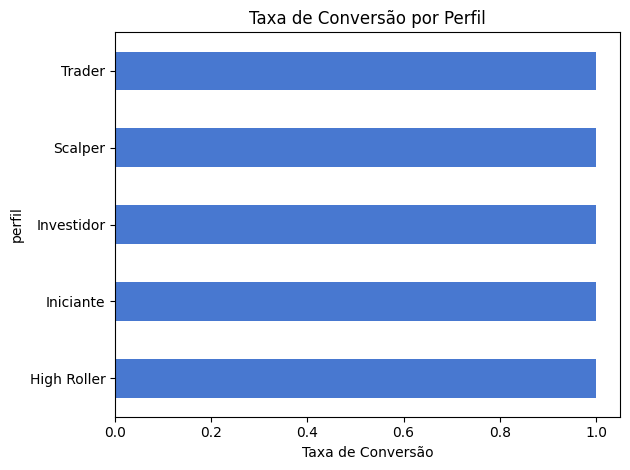

In [16]:
df[df['perfil'].notnull()].groupby('perfil')['status_conversao'].value_counts(normalize=True).unstack().fillna(0)['Convertido'].sort_values().plot(kind='barh', title='Taxa de Conversão por Perfil')
plt.xlabel("Taxa de Conversão")
plt.tight_layout()
plt.show()


## 📅 Leads Cadastrados por Mês

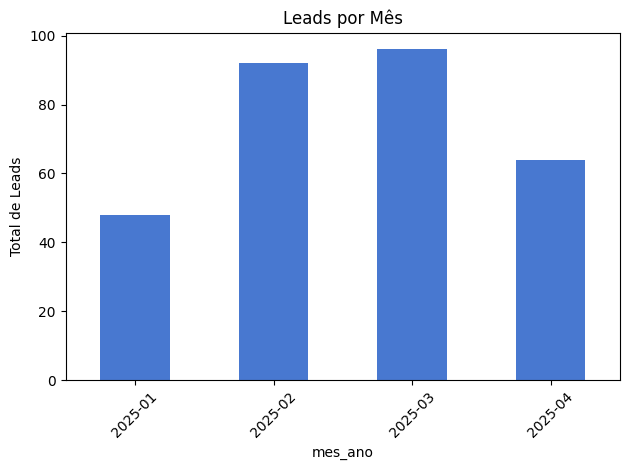

In [17]:
df['mes_ano'] = df['data_cadastro'].dt.to_period('M')
df['mes_ano'].value_counts().sort_index().plot(kind='bar', title='Leads por Mês')
plt.xticks(rotation=45); plt.ylabel("Total de Leads")
plt.tight_layout(); plt.show()
